In [50]:
import random
import csv
import matplotlib.pyplot as plt
import numpy as np
from pulp import LpProblem, LpVariable, LpMaximize, lpSum, value, LpStatus

### UTA

Solver Status: Optimal

Maximized Epsilon (ε): 0.0371

Final Ranking:
--------------------------------------------------
Rank  1 | Alternative 23 | U(a) = 0.6570
Rank  2 | Alternative  9 | U(a) = 0.6487
Rank  3 | Alternative  6 | U(a) = 0.6467
Rank  4 | Alternative  5 | U(a) = 0.6353
Rank  5 | Alternative 17 | U(a) = 0.6240
Rank  6 | Alternative 10 | U(a) = 0.6139
Rank  7 | Alternative  4 | U(a) = 0.6111
Rank  8 | Alternative  7 | U(a) = 0.6096
Rank  9 | Alternative 22 | U(a) = 0.6082
Rank 10 | Alternative  1 | U(a) = 0.6051
Rank 11 | Alternative 19 | U(a) = 0.6020
Rank 12 | Alternative 16 | U(a) = 0.6016
Rank 13 | Alternative 13 | U(a) = 0.5986
Rank 14 | Alternative  8 | U(a) = 0.5901
Rank 15 | Alternative 12 | U(a) = 0.5738
Rank 16 | Alternative  3 | U(a) = 0.5650
Rank 17 | Alternative 20 | U(a) = 0.5615
Rank 18 | Alternative 21 | U(a) = 0.5604
Rank 19 | Alternative 14 | U(a) = 0.5300
Rank 20 | Alternative 26 | U(a) = 0.4971
Rank 21 | Alternative 11 | U(a) = 0.4929
Rank 22 | Alternat

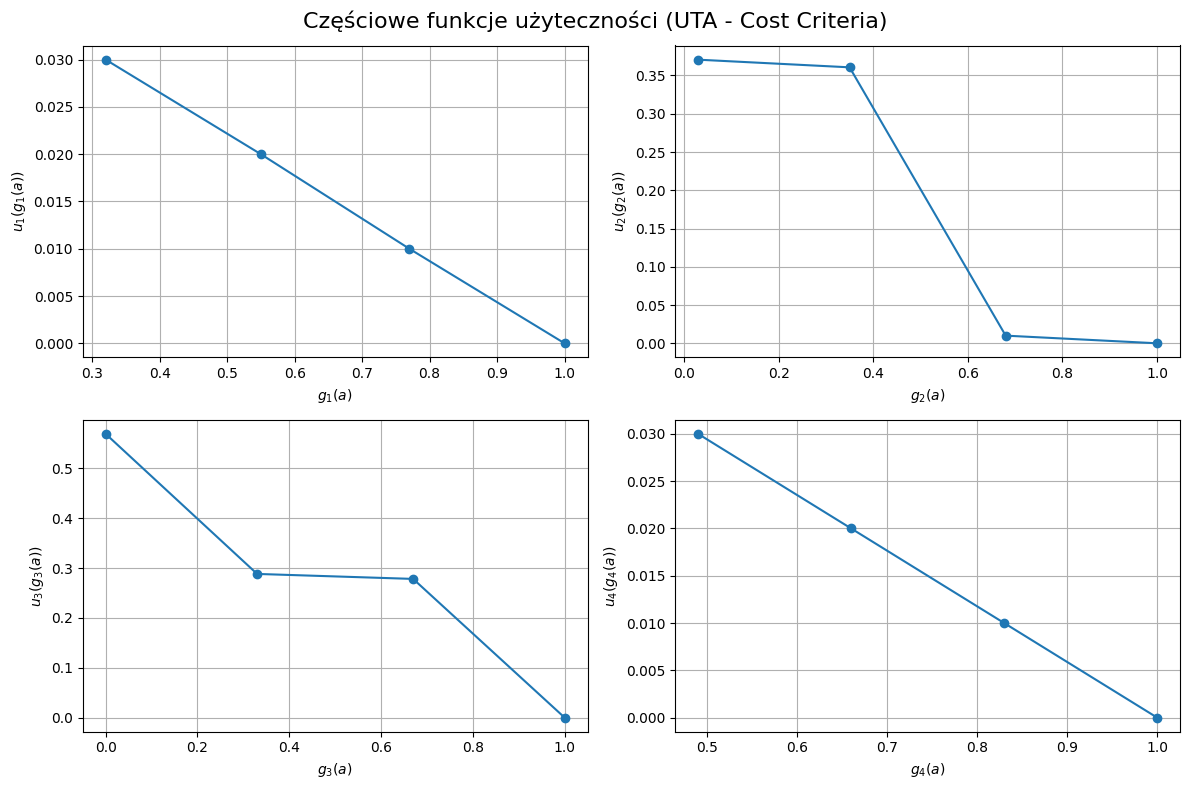

In [51]:
import csv
from pulp import *
import matplotlib.pyplot as plt

prob = LpProblem("UTA", LpMaximize)

n_characteristic_points = 4
file = csv.reader(open("Nuclear waste management.csv"))
raw_data = list(file)
data = {}
for row in raw_data[1:]:
    alt_id = row[0]
    data[alt_id] = [float(val) for val in row[1:]]

G = []
for i in range(4):
    unique_vals = sorted([data[k][i] for k in data.keys()])
    G.append(unique_vals)

prob = LpProblem("True_UTA_Model_Cost", LpMaximize)
epsilon = LpVariable("epsilon", lowBound=0)
prob += epsilon, "Maximize_Epsilon"

omega = LpVariable("omega", lowBound=0.01)

u = [{} for _ in range(4)]
characteristic_points = {}
for i in range(4):
    u[i] = {}
    characteristic_points[i] = []
    for j in range(1, n_characteristic_points + 1):
        point = round(G[i][0] + (j - 1) / (n_characteristic_points - 1) * (G[i][-1] - G[i][0]), 2)
        characteristic_points[i].append(point)
        var_name = f"u_C{i+1}_{str(point).replace('.', '_')}"
        if point not in u[i]:
            u[i][point] = LpVariable(var_name, lowBound=0)

    characteristic_points[i] = sorted(set(characteristic_points[i]))

def get_u_interpolated(criterion_idx, eval_val):
    cps = characteristic_points[criterion_idx]
    if eval_val <= cps[0]: return u[criterion_idx][cps[0]]
    if eval_val >= cps[-1]: return u[criterion_idx][cps[-1]]
    for j in range(len(cps) - 1):
        if cps[j] <= eval_val <= cps[j+1]:
            x_current = cps[j]
            x_next = cps[j+1]
            if x_current == x_next: return u[criterion_idx][x_current]
            u_current = u[criterion_idx][x_current]
            u_next = u[criterion_idx][x_next]
            proportion = (eval_val - x_current) / (x_next - x_current)
            return u_current + proportion * (u_next - u_current)

pairs = [('14', '25'), ('14', '11'), ('13', '20'), ('4', '27'), ('6', '7')]
for a, b in pairs:
    u_a = lpSum([get_u_interpolated(i, data[str(a)][i]) for i in range(4)])
    u_b = lpSum([get_u_interpolated(i, data[str(b)][i]) for i in range(4)])
    prob += u_a - u_b >= epsilon, f"Pref_{a}_{b}"

prob += lpSum([u[i][characteristic_points[i][0]] for i in range(4)]) == 1, "Normalize_Sum_Max"
for i in range(4):
    prob += u[i][characteristic_points[i][-1]] == 0, f"Min_Zero_C{i+1}"
\
for i in range(4):
    for j in range(1, n_characteristic_points):
        prob += u[i][characteristic_points[i][j]] + omega <= u[i][characteristic_points[i][j-1]], f"Monotonicity_C{i+1}_CP{j}"

prob.solve()
print(f"Solver Status: {LpStatus[prob.status]}\n")

if prob.status == 1:
    print(f"Maximized Epsilon (ε): {value(epsilon):.4f}\n")
    U = {}
    for key in data.keys():
        total_utility = sum([value(get_u_interpolated(i, data[key][i])) for i in range(4)])
        U[key] = total_utility

    sorted_variants = sorted(U.items(), key=lambda item: item[1], reverse=True)

    print("Final Ranking:")
    print("-" * 50)
    current_rank, previous_utility = 1, None
    for alt_id, util in sorted_variants:
        if previous_utility is not None and abs(previous_utility - util) > 1e-6:
            current_rank += 1 
        print(f"Rank {current_rank:2d} | Alternative {alt_id:>2s} | U(a) = {util:.4f}")
        previous_utility = util

    plt.close('all')
    plt.figure(figsize=(12, 8))
    plt.suptitle('Częściowe funkcje użyteczności (UTA - Cost Criteria)', fontsize=16)
    for i in range(4):
        plt.subplot(2, 2, i + 1)
        plt.plot(characteristic_points[i], [value(u[i][v]) for v in characteristic_points[i]], marker='o')
        plt.xlabel(f'$g_{i+1}(a)$')
        plt.ylabel(f'$u_{i+1}(g_{i+1}(a))$')
        plt.grid()
        
    plt.tight_layout()
    plt.show()

else:
    print("Model is Infeasible. Your preference pairs conflict with each other or the Cost criteria logic.")

### UTAGMS

In [52]:
necessary_preferences = [('14', '25'), ('14', '11'), ('13', '20'), ('4', '27'), ('6', '7')]
# We keep a static copy of the base pairs so we don't accidentally test them
pairs = necessary_preferences.copy() 

alt_ids = list(data.keys())

for i in alt_ids:
    for j in alt_ids:
        if (i, j) in pairs or (j, i) in pairs or i == j:
            continue
            
        prob = LpProblem("UTAGMS_Cost_Necessary", LpMaximize)
        epsilon = LpVariable("epsilon", lowBound=0)
        prob += epsilon, "Maximize_Epsilon"

        omega = LpVariable("omega", lowBound=0.00)

        u = [{} for _ in range(4)]
        characteristic_points = {}
        for k in range(4):
            u[k] = {}
            characteristic_points[k] = []
            for l in range(1, n_characteristic_points + 1):
                point = round(G[k][0] + (l - 1) / (n_characteristic_points - 1) * (G[k][-1] - G[k][0]), 2)
                characteristic_points[k].append(point)
                var_name = f"u_C{k+1}_{str(point).replace('.', '_')}"
                if point not in u[k]:
                    u[k][point] = LpVariable(var_name, lowBound=0)

            characteristic_points[k] = sorted(set(characteristic_points[k]))

        def get_u_interpolated(criterion_idx, eval_val):
            cps = characteristic_points[criterion_idx]
            if eval_val <= cps[0]: return u[criterion_idx][cps[0]]
            if eval_val >= cps[-1]: return u[criterion_idx][cps[-1]]
            
            for k_idx in range(len(cps) - 1):
                if cps[k_idx] <= eval_val <= cps[k_idx+1]:
                    x_current = cps[k_idx]
                    x_next = cps[k_idx+1]
                    if x_current == x_next:
                        return u[criterion_idx][x_current]
                    
                    u_current = u[criterion_idx][x_current]
                    u_next = u[criterion_idx][x_next]
                    proportion = (eval_val - x_current) / (x_next - x_current)
                    return u_current + proportion * (u_next - u_current)
                
        _pairs = pairs + [(str(j), str(i))]
        
        for a, b in _pairs:
            u_a = lpSum([get_u_interpolated(k, data[str(a)][k]) for k in range(4)])
            u_b = lpSum([get_u_interpolated(k, data[str(b)][k]) for k in range(4)])
            prob += u_a - u_b >= epsilon, f"Pref_{a}_{b}"

        prob += lpSum([u[k][characteristic_points[k][0]] for k in range(4)]) == 1, "Normalize_Sum_Max"
        for k in range(4):
            prob += u[k][characteristic_points[k][-1]] == 0, f"Min_Zero_C{k+1}"

        for k in range(4):
            for l in range(1, len(characteristic_points[k])):
                val_current = characteristic_points[k][l-1]
                val_next = characteristic_points[k][l]
                prob += u[k][val_next] <= u[k][val_current] - omega, f"Monotonicity_C{k+1}_CP{l}"

        prob.solve()
        
        if prob.status == 1:
            if value(epsilon) <= 1e-6:
                necessary_preferences.append((str(i), str(j)))
        elif prob.status == -1:
            necessary_preferences.append((str(i), str(j)))

essential_pairs = necessary_preferences

In [53]:
print("\nNecessary Preferences:")
for pref in necessary_preferences:
    print(f"  {pref[0]} > {pref[1]}")


Necessary Preferences:
  14 > 25
  14 > 11
  13 > 20
  4 > 27
  6 > 7
  2 > 25
  4 > 13
  4 > 20
  4 > 25
  4 > 26
  5 > 2
  5 > 3
  5 > 8
  5 > 11
  5 > 14
  5 > 17
  5 > 25
  6 > 13
  6 > 16
  6 > 20
  6 > 21
  6 > 25
  6 > 26
  7 > 13
  7 > 16
  7 > 20
  7 > 25
  7 > 26
  8 > 2
  8 > 11
  8 > 14
  8 > 25
  9 > 25
  9 > 26
  10 > 1
  10 > 4
  10 > 13
  10 > 20
  10 > 25
  10 > 26
  10 > 27
  11 > 2
  11 > 25
  12 > 21
  12 > 25
  12 > 26
  13 > 25
  13 > 26
  14 > 2
  16 > 13
  16 > 20
  16 > 25
  16 > 26
  17 > 2
  17 > 3
  17 > 8
  17 > 11
  17 > 14
  17 > 25
  18 > 27
  19 > 25
  20 > 25
  20 > 26
  22 > 19
  22 > 25
  23 > 21
  23 > 25
  23 > 26
  24 > 27


In [54]:
import networkx as nx

In [55]:
def build_preference_graph(preferences):
    Gr = nx.DiGraph()
    Gr.add_edges_from(preferences)
    Gr.add_nodes_from([str(i) for i in range(1, len(data.keys()) + 1)])

    Hasse_Graph = nx.transitive_reduction(Gr)

    pos = {}
    for layer, nodes in enumerate(nx.topological_generations(Hasse_Graph)):
        x_offset = (len(nodes) - 1) / 2.0 
        for i, node in enumerate(nodes):
            pos[node] = (i - x_offset, -layer) 

    plt.figure(figsize=(18, 12))

    nx.draw(
        Hasse_Graph, 
        pos, 
        with_labels=True, 
        node_size=2000, 
        node_color="lightblue", 
        font_size=12, 
        font_weight="bold", 
        arrows=True, 
        arrowsize=20,
        edge_color="gray"
    )

    plt.title("Hasse Diagram of Necessary Preferences (Top-Down)", fontsize=14)
    plt.show()

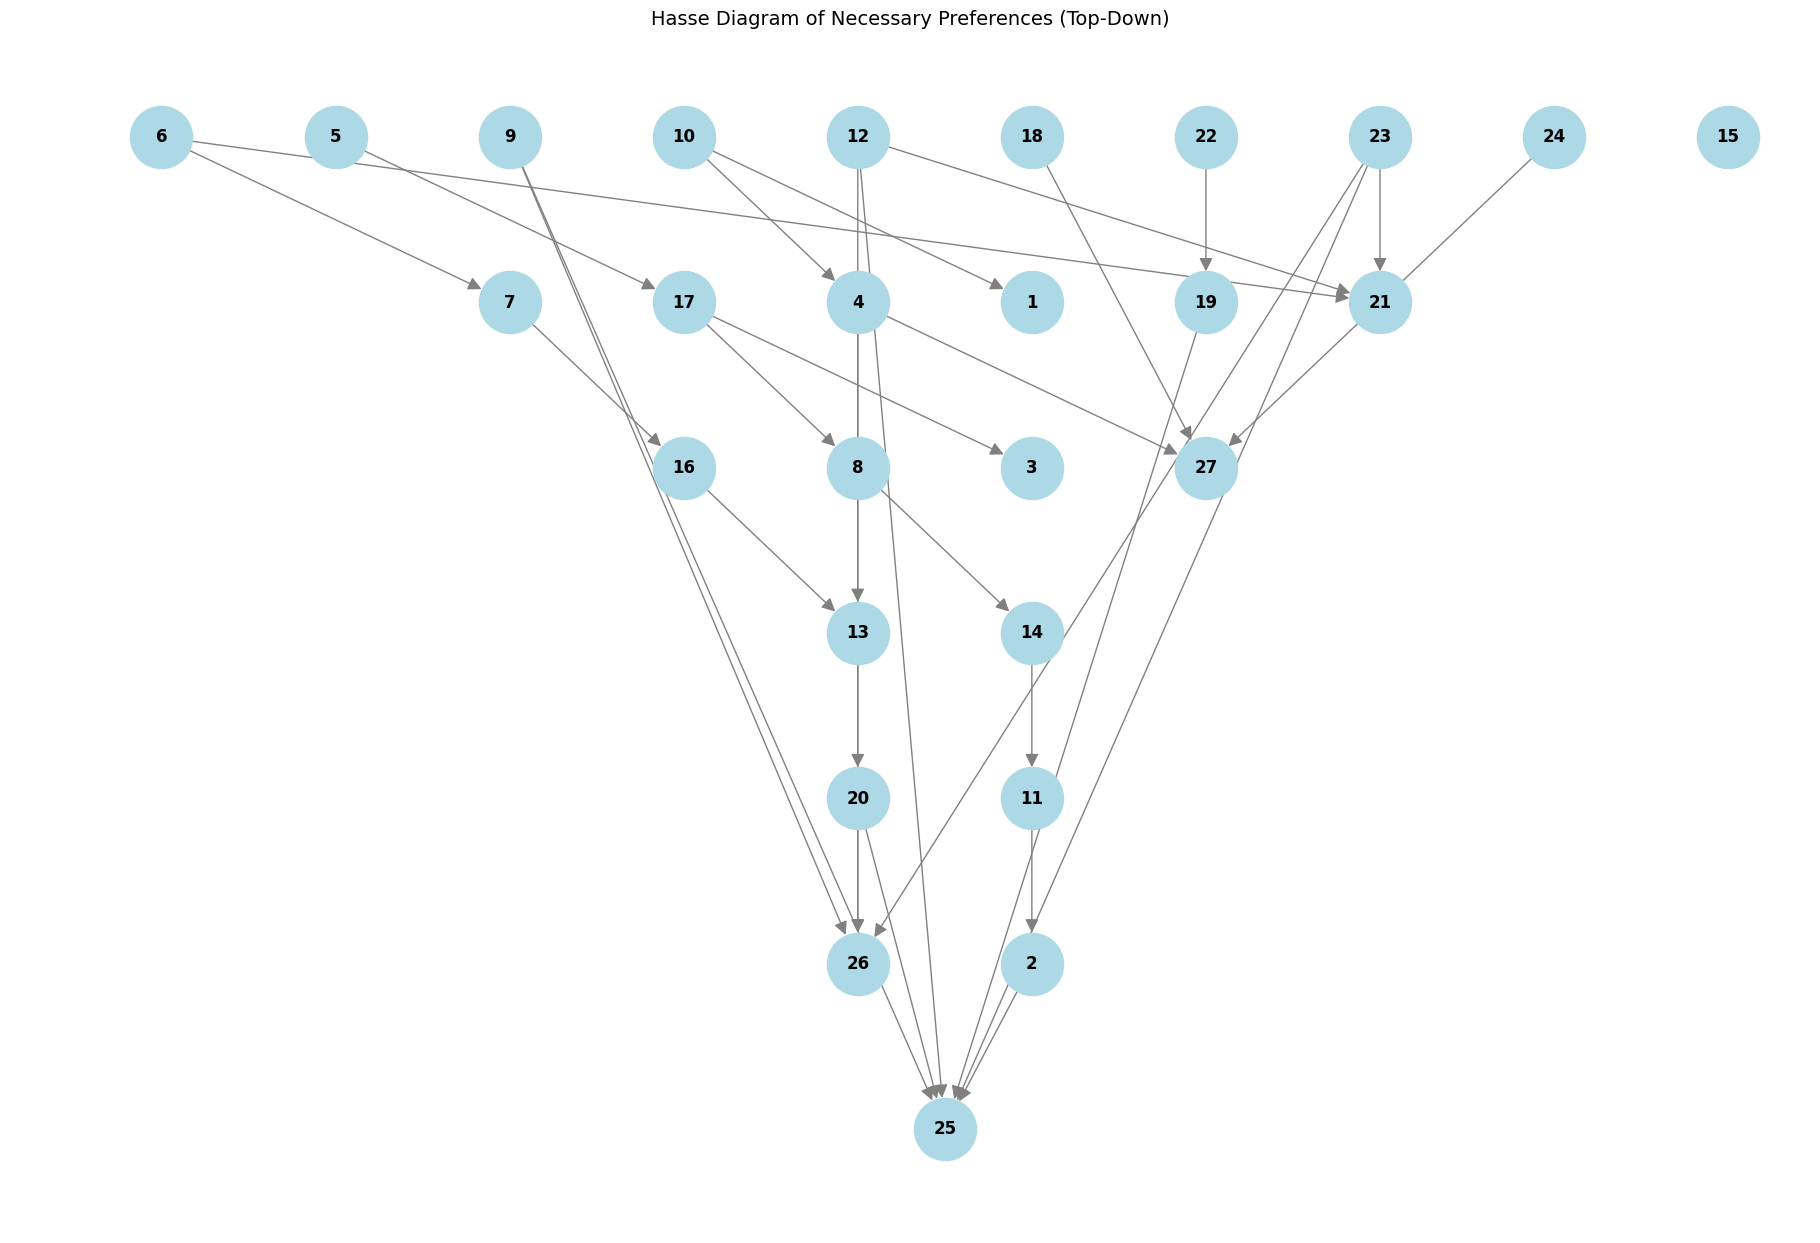

In [56]:
build_preference_graph(essential_pairs)

### Representative utility function

Maximized Representative Function (M*ε - δ): 16.7561
Final Ranking:
--------------------------------------------------
Rank  1 | Alternative 23 | U(a) = 0.6926
Rank  2 | Alternative 22 | U(a) = 0.6868
Rank  3 | Alternative  5 | U(a) = 0.6866
Rank  4 | Alternative  9 | U(a) = 0.6790
Rank  5 | Alternative 19 | U(a) = 0.6697
Rank  6 | Alternative 17 | U(a) = 0.6695
Rank  7 | Alternative  6 | U(a) = 0.6608
Rank  8 | Alternative  8 | U(a) = 0.6493
Rank  9 | Alternative  7 | U(a) = 0.6437
Rank 10 | Alternative 10 | U(a) = 0.6345
Rank 11 | Alternative 16 | U(a) = 0.6189
Rank 12 | Alternative  4 | U(a) = 0.6134
Rank 13 | Alternative 14 | U(a) = 0.5967
Rank 14 | Alternative 13 | U(a) = 0.5963
Rank 15 | Alternative 12 | U(a) = 0.5835
Rank 16 | Alternative 11 | U(a) = 0.5796
Rank 17 | Alternative 20 | U(a) = 0.5792
Rank 18 | Alternative  1 | U(a) = 0.5705
Rank 19 | Alternative  2 | U(a) = 0.5625
Rank 20 | Alternative 21 | U(a) = 0.5496
Rank 21 | Alternative  3 | U(a) = 0.5483
Rank 22 | Alternativ

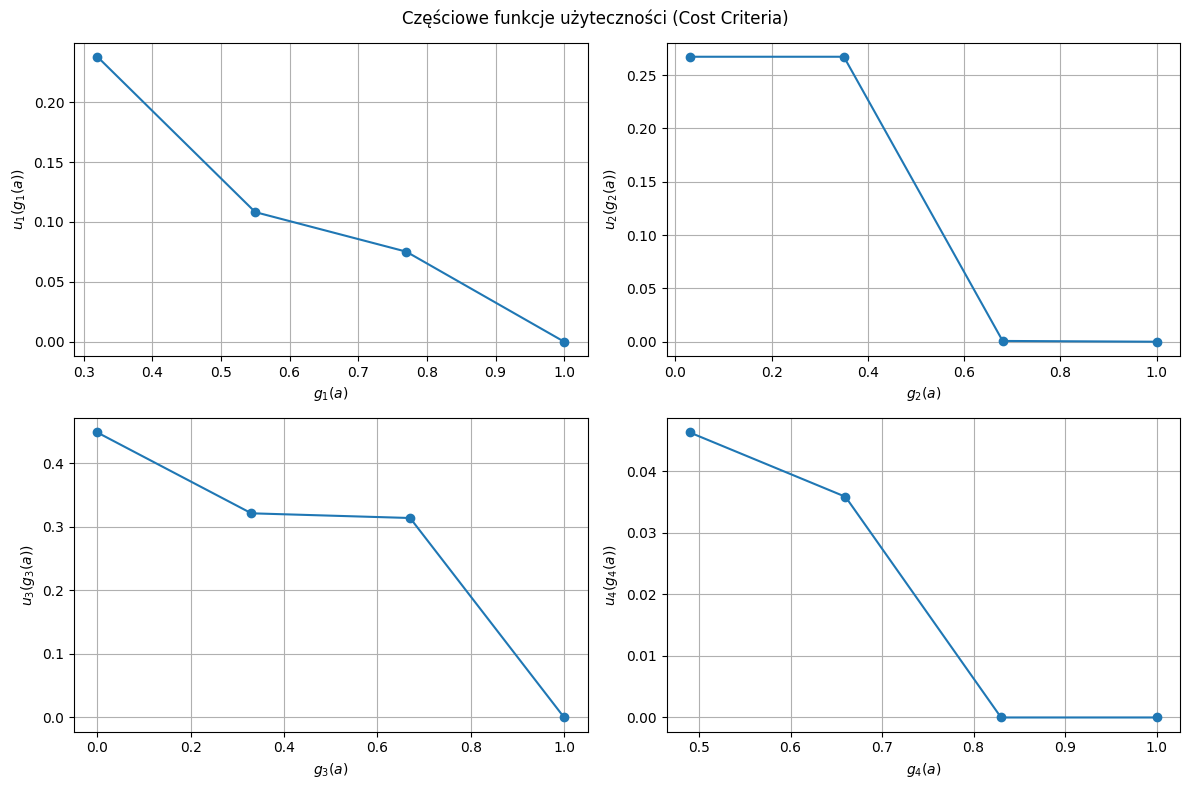

In [61]:
pairs = necessary_preferences.copy()
prob = LpProblem("UTAGMS_Cost_Representative", LpMaximize)

epsilon_val = 0.0371 - 0.02
delta = LpVariable("delta", lowBound=0)
M = 1000

prob += M * epsilon_val - delta, "Representative_Function"

omega = LpVariable("omega", lowBound=0.00)

u = [{} for _ in range(4)]
characteristic_points = {}
for k in range(4):
    u[k] = {}
    characteristic_points[k] = []
    for l in range(1, n_characteristic_points + 1):
        point = round(G[k][0] + (l - 1) / (n_characteristic_points - 1) * (G[k][-1] - G[k][0]), 2)
        characteristic_points[k].append(point)
        var_name = f"u_C{k+1}_{str(point).replace('.', '_')}"
        if point not in u[k]:
            u[k][point] = LpVariable(var_name, lowBound=0)

    characteristic_points[k] = sorted(set(characteristic_points[k]))

def get_u_interpolated(criterion_idx, eval_val):
    cps = characteristic_points[criterion_idx]
    if eval_val <= cps[0]: return u[criterion_idx][cps[0]]
    if eval_val >= cps[-1]: return u[criterion_idx][cps[-1]]
    for k in range(len(cps) - 1):
        if cps[k] <= eval_val <= cps[k+1]:
            x_current = cps[k]
            x_next = cps[k+1]
            if x_current == x_next:
                return u[criterion_idx][x_current]
            u_current = u[criterion_idx][x_current]
            u_next = u[criterion_idx][x_next]
            proportion = (eval_val - x_current) / (x_next - x_current)
            return u_current + proportion * (u_next - u_current)

for a, b in pairs:
    u_a = lpSum([get_u_interpolated(k, data[str(a)][k]) for k in range(4)])
    u_b = lpSum([get_u_interpolated(k, data[str(b)][k]) for k in range(4)])
    prob += u_a - u_b >= epsilon_val, f"Pref_{a}_{b}"

alt_ids = list(data.keys())
for i in range(len(alt_ids)):
    for j in range(i+1, len(alt_ids)):
        alt_i = alt_ids[i]
        alt_j = alt_ids[j]
        if (alt_i, alt_j) in pairs or (alt_j, alt_i) in pairs:
            continue
        u_i = lpSum([get_u_interpolated(k, data[alt_i][k]) for k in range(4)])
        u_j = lpSum([get_u_interpolated(k, data[alt_j][k]) for k in range(4)])
        prob += u_i - u_j <= delta, f"Indiff_{alt_i}_{alt_j}"
        prob += u_j - u_i <= delta, f"Indiff_{alt_j}_{alt_i}"

prob += lpSum([u[k][characteristic_points[k][0]] for k in range(4)]) == 1, "Normalize_Sum_Max"
for k in range(4):
    prob += u[k][characteristic_points[k][-1]] == 0, f"Min_Zero_C{k+1}"

for k in range(4):
    for l in range(1, len(characteristic_points[k])):
        val_current = characteristic_points[k][l-1]
        val_next = characteristic_points[k][l]
        prob += u[k][val_next] <= u[k][val_current] - omega, f"Monotonicity_C{k+1}_CP{l}"

prob.solve()

if prob.status == 1:
    print(f"Maximized Representative Function (M*ε - δ): {value(M * epsilon_val - delta):.4f}")
    
    U = {}
    for key in data.keys():
        total_utility = sum([value(get_u_interpolated(i, data[key][i])) for i in range(4)])
        U[key] = total_utility

    sorted_variants = sorted(U.items(), key=lambda item: item[1], reverse=True)
    print("Final Ranking:")
    print("-" * 50)
    current_rank, actual_position, previous_utility = 1, 1, None
    for alt_id, util in sorted_variants:
        if previous_utility is not None and abs(previous_utility - util) > 1e-6:
            current_rank = actual_position 
        print(f"Rank {current_rank:2d} | Alternative {alt_id:>2s} | U(a) = {util:.4f}")
        previous_utility = util
        actual_position += 1

    plt.close('all')
    plt.figure(figsize=(12, 8))
    plt.suptitle("Częściowe funkcje użyteczności (Cost Criteria)")
    for i in range(4):
        plt.subplot(2, 2, i + 1)
        plt.plot(characteristic_points[i], [value(u[i][v]) for v in characteristic_points[i]], marker='o')
        plt.xlabel(f'$g_{i+1}(a)$')
        plt.ylabel(f'$u_{i+1}(g_{i+1}(a))$')
        plt.grid()
        
    plt.tight_layout()
    plt.show()
else:
    print(f"Model is Infeasible!")